# Evaluation analysis

## 1. Output length vs. score — the anti-verbosity hypothesis

Does producing **shorter** game moves correlate with **higher** clembench performance? We test this for the Qwen3.5 **2B** and **9B** model families using their playpen-eval runs (SFT + all DPO variants).

Three angles:
1. **Model-level** — across variants, does lower mean output length track higher clemscore? (cleanest: all variants face the same games)
2. **Per-episode** — within played rounds, does a more verbose transcript get a lower quality score? (game-normalised to remove the game confound)
3. **Aborts** — are aborted episodes more verbose than played ones? (the proposed mechanism: verbosity → parse failure → abort)

Verbosity proxy: **words per move** (and chars per move). Run this notebook from the repo root.

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
from IPython.display import display
%matplotlib inline

REPO = Path.cwd()
if not (REPO / "playpen-eval").exists():
    for p in REPO.parents:
        if (p / "playpen-eval").exists():
            REPO = p
            break
PLAYPEN_EVAL = REPO / "playpen-eval"
print("repo:", REPO)
assert PLAYPEN_EVAL.exists(), "playpen-eval/ not found — run from the repo root"

repo: /project/marika/Reflections-Augmented-SFT-for-Dialogue-Games


In [2]:
# --- helpers: parse interactions.json (model moves) and scores.json (outcome) ---

def get_model_players(inter):
    """Players actually generated by the model (exclude GM and programmatic roles)."""
    players = inter.get("players", {})
    return {p for p, info in players.items()
            if p != "GM" and info.get("model_name") != "programmatic"}

def model_move_texts(inter):
    """All text the model generated this episode ('get message' from a model player)."""
    mp = get_model_players(inter)
    out = []
    for turn in inter.get("turns", []):
        for msg in turn:
            a = msg.get("action", {})
            if a.get("type") == "get message" and msg.get("from") in mp:
                c = a.get("content", "")
                out.append(c if isinstance(c, str) else json.dumps(c))
    return out

def episode_outcome_score(scores_path):
    """Return (outcome, main_score). outcome in {success, failed, aborted, None}."""
    epi = json.load(open(scores_path)).get("episode scores", {})
    aborted = epi.get("Aborted") in (1, True)
    success = epi.get("Success") in (1, True)
    lose    = epi.get("Lose") in (1, True)
    outcome = "aborted" if aborted else "success" if success else "failed" if lose else None
    main = epi.get("Main Score")
    main = float(main) if isinstance(main, (int, float)) and main == main else np.nan
    return outcome, main

def load_eval_episodes(eval_dir, model_name):
    """One row per played instance: length metrics + outcome + quality score."""
    rows = []
    clem = Path(eval_dir) / "clem"
    for ip in clem.rglob("interactions.json"):
        sp = ip.parent / "scores.json"
        if not sp.exists():
            continue
        try:
            inter = json.load(open(ip))
        except Exception:
            continue
        game, experiment, instance = ip.parts[-4], ip.parts[-3], ip.parts[-2]
        moves = model_move_texts(inter)
        words = [len(m.split()) for m in moves]
        chars = [len(m) for m in moves]
        outcome, main = episode_outcome_score(sp)
        rows.append(dict(
            model=model_name, game=game, experiment=experiment, instance=instance,
            outcome=outcome, main_score=main, n_moves=len(moves),
            total_words=int(np.sum(words)) if words else 0,
            mean_words=float(np.mean(words)) if words else np.nan,
            total_chars=int(np.sum(chars)) if chars else 0,
            mean_chars=float(np.mean(chars)) if chars else np.nan,
        ))
    return pd.DataFrame(rows)

In [3]:
# --- discover Qwen 2B / 9B eval dirs (model_name + clemscore from the .val.json) ---

def discover_qwen_evals(size_prefixes=("Qwen3.5-2B", "Qwen3.5-9B")):
    found = {}
    for d in sorted(PLAYPEN_EVAL.iterdir()):
        if not d.is_dir():
            continue
        vjs = list(d.glob("*.val.json"))
        if not vjs or not (d / "clem").exists():
            continue
        model = vjs[0].name[:-len(".val.json")]
        if not any(model.startswith(p) for p in size_prefixes):
            continue
        # Only canonical post-EOS-fix checkpoints. The early SFT runs
        # (Qwen3.5-2B-sft, -sft-spg50, before 2026-06-11) ship no
        # generation_config -> runaway hallucination. Their evals are invalid
        # and, being a length artifact, would badly distort THIS study.
        if not model.endswith("-merged"):
            continue
        if model in found:  # dedupe (temp=0 is deterministic; keep first)
            continue
        try:
            clem = json.load(open(vjs[0])).get("clemscore", np.nan)
        except Exception:
            clem = np.nan
        found[model] = dict(eval_dir=d, clemscore=clem)
    return found

evals = discover_qwen_evals()
print(f"{'clemscore':>9}  model")
for m, info in sorted(evals.items(), key=lambda kv: kv[1]['clemscore']):
    print(f"{info['clemscore']:>9.2f}  {m:45s}  ({info['eval_dir'].name})")

clemscore  model
     0.00  Qwen3.5-2B-dpo-reason-move-merged              (2026-06-12T13-37-41)
    10.10  Qwen3.5-2B-dpo-trial-merged                    (2026-06-11T19-47-21)
    23.34  Qwen3.5-2B-dpo-onpolicy-v2-merged              (2026-06-15T12-04-35)
    24.71  Qwen3.5-2B-dpo-onpolicy-merged                 (2026-06-15T08-50-01)
    26.30  Qwen3.5-9B-dpo-all-merged                      (qwen3.5-9b-dpo-all)
    30.06  Qwen3.5-2B-dpo-feedback-retry-merged           (2026-06-12T13-37-17)
    31.26  Qwen3.5-2B-sft-spg50-merged                    (2026-06-11T14-10-14)
    38.05  Qwen3.5-2B-sft-full-merged                     (qwen3.5-2b-sft)
    49.06  Qwen3.5-9B-dpo-aborted-failed-merged           (2026-06-22T12-04-10)
    51.03  Qwen3.5-2B-dpo-aborted-only-seed123-merged     (2026-06-15T15-02-09)
    54.28  Qwen3.5-2B-dpo-aborted-only-merged             (2026-06-15T14-02-58)
    57.00  Qwen3.5-9B-dpo-antibleed-verifstrat-merged     (2026-06-23T15-22-29)
    58.82  Qwen3.5-9B-sft-ful

In [4]:
# --- build the per-episode table across all variants ---
frames = []
for m, info in evals.items():
    df = load_eval_episodes(info["eval_dir"], m)
    df["clemscore"] = info["clemscore"]
    df["size"] = "2B" if "2B" in m else "9B"
    frames.append(df)
EP = pd.concat(frames, ignore_index=True)
print("episodes:", len(EP), "| models:", EP.model.nunique())
print(EP.outcome.value_counts(dropna=False).to_dict())
EP.head()

episodes: 1015 | models: 15
{'aborted': 372, 'failed': 327, 'success': 316}


,model,game,experiment,instance,outcome,main_score,n_moves,total_words,mean_words,total_chars,mean_chars,clemscore,size
0,Qwen3.5-2B-sft-spg50-merged,wordle,medium_frequency_words_no_clue_no_critic,instance_00014,aborted,NaN,6,169,28.166667,961,160.166667,31.26,2B
1,Qwen3.5-2B-sft-spg50-merged,wordle,medium_frequency_words_no_clue_no_critic,instance_00007,aborted,NaN,6,169,28.166667,961,160.166667,31.26,2B
2,Qwen3.5-2B-sft-spg50-merged,wordle,high_frequency_words_no_clue_no_critic,instance_00007,aborted,NaN,6,169,28.166667,961,160.166667,31.26,2B
3,Qwen3.5-2B-sft-spg50-merged,guesswhat,Abs_Level_3,instance_00008,success,100.0,5,25,5.000000,152,30.400000,31.26,2B
4,Qwen3.5-2B-sft-spg50-merged,guesswhat,Abs_Level_2,instance_00007,failed,0.0,9,44,4.888889,262,29.111111,31.26,2B


### 1a. Model-level: mean output length vs clemscore

Each point is one model variant. If anti-verbosity drives performance we expect a **negative** correlation between mean words/move and clemscore.

,model,size,clemscore,mean_words,mean_chars,abort_rate
5,Qwen3.5-2B-dpo-reason-move-merged,2B,0.00,199.38,1222.03,0.94
6,Qwen3.5-2B-dpo-trial-merged,2B,10.10,76.69,851.56,0.83
4,Qwen3.5-2B-dpo-onpolicy-v2-merged,2B,23.34,11.05,64.82,0.37
3,Qwen3.5-2B-dpo-onpolicy-merged,2B,24.71,14.20,78.59,0.49
11,Qwen3.5-9B-dpo-all-merged,9B,26.30,10.18,59.18,0.53
2,Qwen3.5-2B-dpo-feedback-retry-merged,2B,30.06,11.00,60.40,0.57
8,Qwen3.5-2B-sft-spg50-merged,2B,31.26,11.89,72.25,0.26
7,Qwen3.5-2B-sft-full-merged,2B,38.05,11.98,68.88,0.18
9,Qwen3.5-9B-dpo-aborted-failed-merged,9B,49.06,14.50,84.77,0.35
1,Qwen3.5-2B-dpo-aborted-only-seed123-merged,2B,51.03,10.49,58.60,0.16


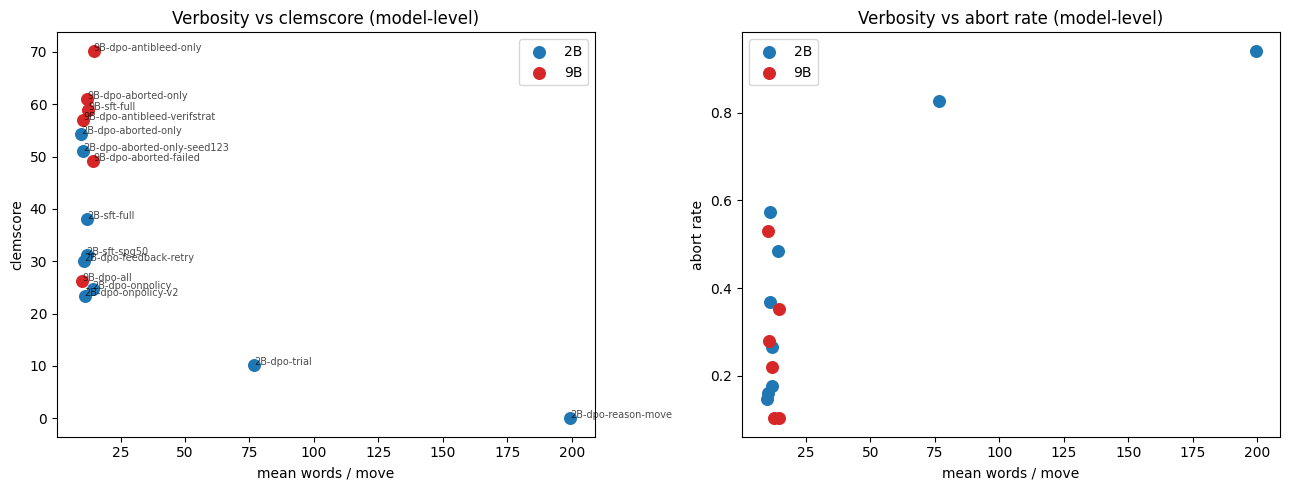


Correlation: mean words/move  vs  clemscore
  all n=15  Pearson r=-0.641 (p=0.010)   Spearman rho=-0.193 (p=0.491)
  2B  n=9  Pearson r=-0.761 (p=0.017)   Spearman rho=-0.800 (p=0.010)
  9B  n=6  Pearson r=+0.565 (p=0.243)   Spearman rho=+0.600 (p=0.208)


In [5]:
agg = (EP.groupby(["model", "size", "clemscore"])
         .agg(mean_words=("mean_words", "mean"),
              mean_chars=("mean_chars", "mean"),
              abort_rate=("outcome", lambda s: (s == "aborted").mean()))
         .reset_index()
         .sort_values("clemscore"))
display(agg.round(2))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
colors = {"2B": "tab:blue", "9B": "tab:red"}
for size, c in colors.items():
    sub = agg[agg["size"] == size]
    ax[0].scatter(sub.mean_words, sub.clemscore, c=c, s=70, label=size)
    for _, r in sub.iterrows():
        short = r.model.replace("Qwen3.5-", "").replace("-merged", "")
        ax[0].annotate(short, (r.mean_words, r.clemscore), fontsize=7, alpha=.7)
ax[0].set(xlabel="mean words / move", ylabel="clemscore",
          title="Verbosity vs clemscore (model-level)")
ax[0].legend()

for size, c in colors.items():
    sub = agg[agg["size"] == size]
    ax[1].scatter(sub.mean_words, sub.abort_rate, c=c, s=70, label=size)
ax[1].set(xlabel="mean words / move", ylabel="abort rate",
          title="Verbosity vs abort rate (model-level)")
ax[1].legend()
plt.tight_layout(); plt.show()

print("\nCorrelation: mean words/move  vs  clemscore")
for label, sub in [("all", agg), ("2B", agg[agg['size'] == '2B']), ("9B", agg[agg['size'] == '9B'])]:
    if len(sub) >= 3:
        r, pr = stats.pearsonr(sub.mean_words, sub.clemscore)
        rho, ps = stats.spearmanr(sub.mean_words, sub.clemscore)
        print(f"  {label:3s} n={len(sub)}  Pearson r={r:+.3f} (p={pr:.3f})   Spearman rho={rho:+.3f} (p={ps:.3f})")

### 1b. Per-episode: output length vs quality (played episodes)

Within played rounds (success/failed, excluding aborts), does a more verbose transcript score lower? Pooling across games confounds this (games differ in natural length & difficulty), so we also report a **game-normalised** correlation: z-score both length and score *within each game*, then correlate.

Raw pooled (per size):
  [2B] n= 343  Spearman(mean_words, main_score) rho=+0.155  p=0.004
  [9B] n= 300  Spearman(mean_words, main_score) rho=+0.238  p=3.1e-05

Game-normalised (removes per-game confound):
  [2B] n= 343  Spearman(z_words, z_score) rho=-0.065  p=0.23
  [9B] n= 300  Spearman(z_words, z_score) rho=+0.092  p=0.11


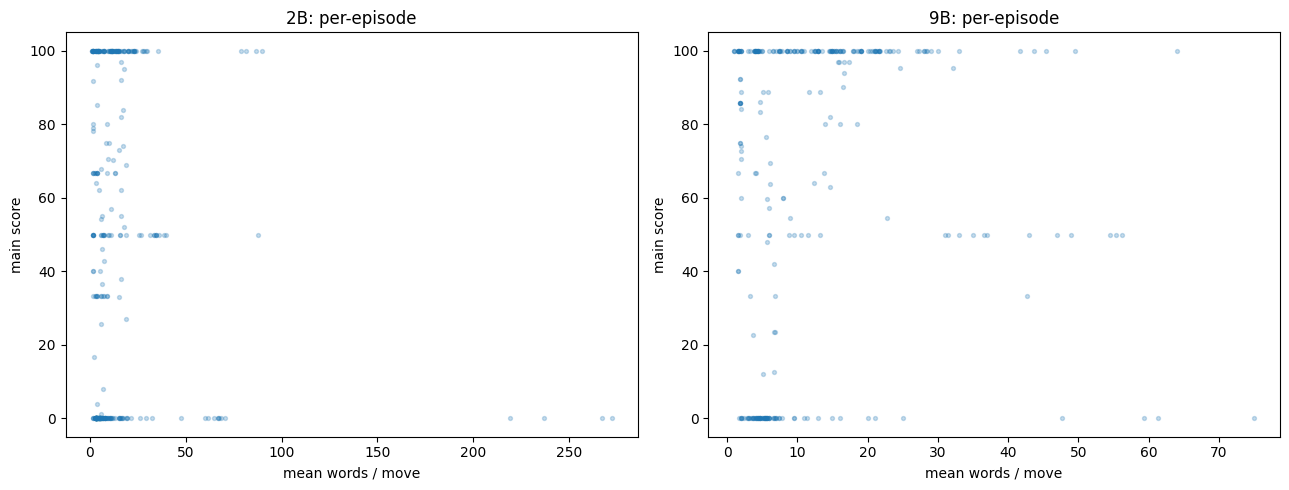

In [6]:
played = EP[EP.outcome.isin(["success", "failed"]) & EP.main_score.notna() & EP.mean_words.notna()].copy()

print("Raw pooled (per size):")
for size in ["2B", "9B"]:
    sub = played[played["size"] == size]
    rho, p = stats.spearmanr(sub.mean_words, sub.main_score)
    print(f"  [{size}] n={len(sub):4d}  Spearman(mean_words, main_score) rho={rho:+.3f}  p={p:.2g}")

def zscore(s):
    sd = s.std(ddof=0)
    return (s - s.mean()) / sd if sd > 0 else s * 0.0

played["z_words"] = played.groupby(["size", "game"])["mean_words"].transform(zscore)
played["z_score"] = played.groupby(["size", "game"])["main_score"].transform(zscore)

print("\nGame-normalised (removes per-game confound):")
for size in ["2B", "9B"]:
    sub = played[played["size"] == size].dropna(subset=["z_words", "z_score"])
    rho, p = stats.spearmanr(sub.z_words, sub.z_score)
    print(f"  [{size}] n={len(sub):4d}  Spearman(z_words, z_score) rho={rho:+.3f}  p={p:.2g}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, size in enumerate(["2B", "9B"]):
    sub = played[played["size"] == size]
    ax[i].scatter(sub.mean_words, sub.main_score, s=8, alpha=.25)
    ax[i].set(title=f"{size}: per-episode", xlabel="mean words / move", ylabel="main score")
plt.tight_layout(); plt.show()

### 1c. Are aborted episodes more verbose?

The proposed mechanism: verbose output → parser can't extract the move → abort. If true, aborted episodes should be more verbose than played ones.

[2B] aborted median=30.8  played median=7.0  Mann-Whitney(aborted>played) p=2.8e-11
[9B] aborted median=4.4  played median=7.4  Mann-Whitney(aborted>played) p=1


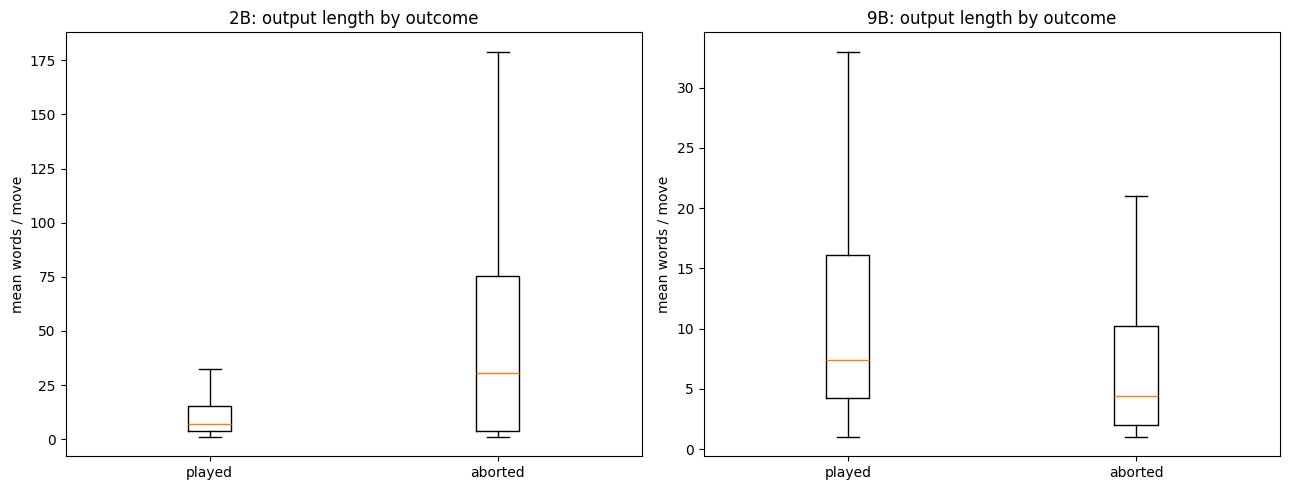

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for i, size in enumerate(["2B", "9B"]):
    sub = EP[(EP["size"] == size) & EP.mean_words.notna()]
    ok = sub[sub.outcome != "aborted"]["mean_words"].dropna()
    ab = sub[sub.outcome == "aborted"]["mean_words"].dropna()
    ax[i].boxplot([ok, ab], showfliers=False)
    ax[i].set_xticks([1, 2]); ax[i].set_xticklabels(["played", "aborted"])
    ax[i].set(title=f"{size}: output length by outcome", ylabel="mean words / move")
    if len(ab) > 5 and len(ok) > 5:
        u, p = stats.mannwhitneyu(ab, ok, alternative="greater")
        print(f"[{size}] aborted median={ab.median():.1f}  played median={ok.median():.1f}  "
              f"Mann-Whitney(aborted>played) p={p:.2g}")
plt.tight_layout(); plt.show()

### Reading the results

- **1a negative correlation** → variants that learned to be terser score higher: the headline anti-verbosity claim, at the model level.
- **1b** tests whether, *holding the model and game fixed*, verbosity tracks lower quality on rounds that were actually played. A weak/null result here with a strong 1c result would mean verbosity mainly hurts via **aborts**, not via degrading played-round quality.
- **1c** is the mechanism check: aborted > played verbosity (one-sided) supports "verbosity → parse failure → abort".

Caveat: clemscore already folds in %Played (which abort rate drives), so 1a and 1c are not fully independent — 1b is the cleaner test of quality-given-played.

## 2. Where verbosity hurts: per-game outcome rates

Which games abort vs fail (lose) most? Verbosity-driven failure should concentrate where abort rates are high — and the abort mechanism (verbose → parse failure) is distinct from losing a played round.

In [8]:
ct = EP.groupby("game").outcome.value_counts(normalize=True).unstack(fill_value=0) * 100
for c in ["success", "failed", "aborted"]:
    if c not in ct:
        ct[c] = 0.0
ct["n"] = EP.groupby("game").size()
ct["non_success"] = ct["aborted"] + ct["failed"]
ct = ct[["success", "failed", "aborted", "non_success", "n"]].sort_values("aborted", ascending=False)
display(ct.round(1))
print("Plain wordle has the highest ABORT rate; guesswhat/imagegame/privateshared fail (lose) most.")

outcome,success,failed,aborted,non_success,n
game,,,,,
wordle,11.1,13.3,75.6,88.9,45
codenames,8.2,31.3,60.5,91.8,195
adventuregame,13.3,32.0,54.7,86.7,75
privateshared,0.0,54.7,45.3,100.0,75
textmapworld,32.0,26.7,41.3,68.0,75
textmapworld_specificroom,48.9,11.1,40.0,51.1,45
textmapworld_graphreasoning,24.4,40.0,35.6,75.6,45
imagegame,16.7,53.3,30.0,83.3,60
wordle_withcritic,71.1,0.0,28.9,28.9,45


Plain wordle has the highest ABORT rate; guesswhat/imagegame/privateshared fail (lose) most.


## 3. Reasoning preamble ("overthinking")

Total words/move conflates legitimate long answers (e.g. taboo clues) with reasoning. A cleaner overthinking proxy is the **preamble**: words *before* the first answer-tag line (e.g. wordle's `explanation:` before `guess:`). It is ~0 for games whose output *is* the answer, and only nonzero where the format permits reasoning before the move — which turns out to be the wordle family.

episodes: 1015


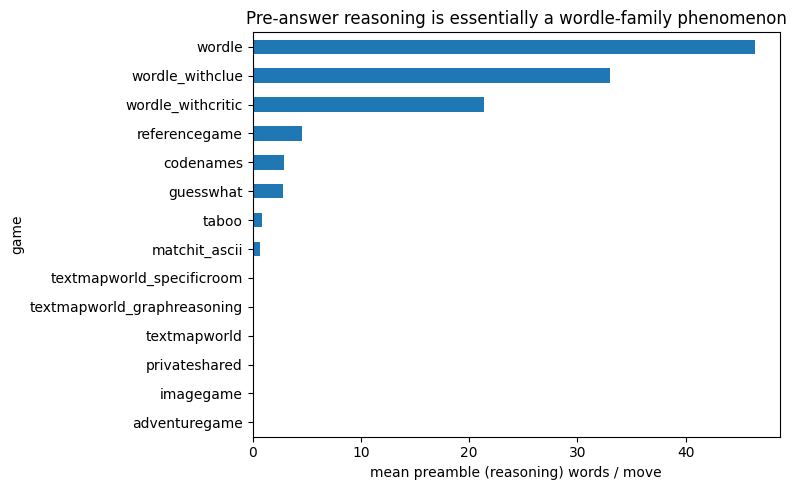

wordle-family preamble by outcome:
  success  n= 72  median=20.8  mean=25.8
  failed   n=  7  median=59.3  mean=58.2
  aborted  n= 56  median=40.2  mean=40.5
  failed  > success preamble: p=2.2e-05
  aborted > success preamble: p=1.7e-06


In [9]:
import re
ANSWER_TAG = re.compile(r'^(clue|targets|guess|question|answer|expression|instruction|prediction|word|letter)\s*:', re.I)

def preamble_words(move):
    """Words before the first answer-tag line = pre-answer reasoning ('overthinking')."""
    lines = move.splitlines()
    for k, ln in enumerate(lines):
        if ANSWER_TAG.match(ln.strip()):
            return sum(len(l.split()) for l in lines[:k])
    return 0  # no recognised answer tag -> no detachable preamble

def load_eval_preamble(eval_dir, model_name):
    rows = []
    for ip in (Path(eval_dir) / "clem").rglob("interactions.json"):
        sp = ip.parent / "scores.json"
        if not sp.exists():
            continue
        mvs = model_move_texts(json.load(open(ip)))
        pre = [preamble_words(m) for m in mvs]
        outcome, _ = episode_outcome_score(sp)
        rows.append(dict(model=model_name, size="2B" if "2B" in model_name else "9B",
                         game=ip.parts[-4], experiment=ip.parts[-3], inst=ip.parts[-2],
                         outcome=outcome, mean_preamble=np.mean(pre) if pre else np.nan))
    return pd.DataFrame(rows)

EPX = pd.concat([load_eval_preamble(info["eval_dir"], m) for m, info in evals.items()], ignore_index=True)
print("episodes:", len(EPX))

pg = EPX.groupby("game").mean_preamble.mean().sort_values()
ax = pg.plot.barh(figsize=(8, 5))
ax.set_xlabel("mean preamble (reasoning) words / move")
ax.set_title("Pre-answer reasoning is essentially a wordle-family phenomenon")
plt.tight_layout(); plt.show()

wf = EPX[EPX.game.str.startswith("wordle") & EPX.mean_preamble.notna()]
print("wordle-family preamble by outcome:")
for oc in ["success", "failed", "aborted"]:
    s = wf[wf.outcome == oc].mean_preamble
    print(f"  {oc:8s} n={len(s):3d}  median={s.median():.1f}  mean={s.mean():.1f}")
su, fa, ab = (wf[wf.outcome == o].mean_preamble.dropna() for o in ["success", "failed", "aborted"])
if len(fa) > 3 and len(su) > 3:
    print("  failed  > success preamble: p=%.2g" % stats.mannwhitneyu(fa, su, alternative="greater").pvalue)
if len(ab) > 3 and len(su) > 3:
    print("  aborted > success preamble: p=%.2g" % stats.mannwhitneyu(ab, su, alternative="greater").pvalue)

## 4. The wordle confound: within- vs between-variant

The preamble↔outcome link looks strong when pooling the wordle family — but that pools easy (clue/critic) and hard (plain) variants. The honest test holds the task fixed (plain wordle) and controls per-instance (compare models on the *same* puzzle). If the effect survives only between variants, it's a difficulty confound, not "overthinking causes losing."

In [10]:
wf = EPX[EPX.game.str.startswith("wordle") & EPX.mean_preamble.notna()].copy()
wf["win"] = (wf.outcome == "success").astype(int)
for scope, sub in [("wordle family", wf), ("plain wordle only", wf[wf.game == "wordle"])]:
    rho, p = stats.spearmanr(sub.mean_preamble, sub.win)
    w = sub[sub.win == 1].mean_preamble.median()
    l = sub[sub.win == 0].mean_preamble.median()
    print(f"[{scope}] n={len(sub)}  win median={w:.1f}  non-win median={l:.1f}  "
          f"Spearman(preamble, win)={rho:+.3f} (p={p:.2g})")
    rhos = []
    for _, grp in sub.groupby(["game", "experiment", "inst"]):
        if grp.win.nunique() > 1 and grp.mean_preamble.nunique() > 1 and len(grp) >= 4:
            r, _ = stats.spearmanr(grp.mean_preamble, grp.win)
            if not np.isnan(r):
                rhos.append(r)
    if rhos:
        print(f"           instance-controlled mean Spearman = {np.mean(rhos):+.3f} over {len(rhos)} instances")

print("\nThe strong family-level negative correlation is a BETWEEN-VARIANT confound:")
print("clue/critic variants are both easier (external info) AND less verbose. Holding the task")
print("fixed (plain wordle) the correlation vanishes -> overthinking looks like a SYMPTOM of")
print("hard positions, not a cause of losing.")

[wordle family] n=135  win median=20.8  non-win median=45.7  Spearman(preamble, win)=-0.459 (p=2.1e-08)
           instance-controlled mean Spearman = -0.227 over 8 instances
[plain wordle only] n=45  win median=53.4  non-win median=47.0  Spearman(preamble, win)=+0.114 (p=0.45)
           instance-controlled mean Spearman = +0.141 over 2 instances

The strong family-level negative correlation is a BETWEEN-VARIANT confound:
clue/critic variants are both easier (external info) AND less verbose. Holding the task
fixed (plain wordle) the correlation vanishes -> overthinking looks like a SYMPTOM of
hard positions, not a cause of losing.


## 5. SFT → DPO per-game decomposition (%Played vs Quality)

Did anti-bleed help by reducing aborts (**%Played** up) or by playing better (**Quality** up)? Decomposing the 9B SFT→anti-bleed lift per game distinguishes the abort-reduction mechanism from the on-policy reinforcement mechanism. (For 9B the gains are Quality-driven, which is why the lift can't be attributed to verbosity/abort reduction.)

In [11]:
# 9B SFT vs anti-bleed-only, decomposed into %Played and Quality (val split)
def per_game_decomp(model_name):
    sub = EP[EP.model == model_name].copy()
    sub["played"] = (sub.outcome != "aborted").astype(float)
    g = sub.groupby("game").agg(pct_played=("played", lambda s: 100 * s.mean()),
                                quality=("main_score", "mean"))  # mean skips NaN -> played only
    g["clem"] = g.pct_played * g.quality / 100
    return g

sft_name, ab_name = "Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-dpo-antibleed-only-merged"
have = set(EP.model.unique())
if sft_name in have and ab_name in have:
    a, b = per_game_decomp(sft_name), per_game_decomp(ab_name)
    cmp = pd.DataFrame({
        "played_sft": a.pct_played, "played_ab": b.pct_played, "played_d": b.pct_played - a.pct_played,
        "qual_sft": a.quality, "qual_ab": b.quality, "qual_d": b.quality - a.quality,
        "clem_sft": a.clem, "clem_ab": b.clem, "clem_d": b.clem - a.clem,
    }).sort_values("clem_d", ascending=False)
    display(cmp.round(1))
    print(f"Overall clemscore: {cmp.clem_sft.mean():.1f} -> {cmp.clem_ab.mean():.1f}")
    print(f"Mean %Played delta: {cmp.played_d.mean():+.1f}   Mean Quality delta: {cmp.qual_d.mean():+.1f}")
    print("Gains Quality-driven, not %Played-driven -> not abort reduction; consistent with")
    print("on-policy reinforcement of correct moves (see discussion).")
else:
    print("Need both models in EP. Available:", sorted(have))

,played_sft,played_ab,played_d,qual_sft,qual_ab,qual_d,clem_sft,clem_ab,clem_d
game,,,,,,,,,
textmapworld,100.0,100.0,0.0,49.3,90.5,41.2,49.3,90.5,41.2
wordle_withcritic,66.7,100.0,33.3,100.0,100.0,0.0,66.7,100.0,33.3
adventuregame,100.0,80.0,-20.0,33.3,83.3,50.0,33.3,66.7,33.3
textmapworld_specificroom,100.0,100.0,0.0,66.7,100.0,33.3,66.7,100.0,33.3
textmapworld_graphreasoning,100.0,100.0,0.0,54.8,88.0,33.2,54.8,88.0,33.2
codenames,76.9,76.9,0.0,20.0,50.0,30.0,15.4,38.5,23.1
privateshared,100.0,100.0,0.0,42.7,49.8,7.1,42.7,49.8,7.1
imagegame,100.0,100.0,0.0,88.5,94.8,6.2,88.5,94.8,6.2
guesswhat,100.0,100.0,0.0,33.3,33.3,0.0,33.3,33.3,0.0


Overall clemscore: 57.0 -> 70.2
Mean %Played delta: +1.0   Mean Quality delta: +12.0
Gains Quality-driven, not %Played-driven -> not abort reduction; consistent with
on-policy reinforcement of correct moves (see discussion).


## 6. Caveat — eval-instance exclusion (read before trusting any DPO lift)

DPO raises the probability of the `chosen` completion, which is the *correct move for that context*. So if anti-bleed / correction pairs were harvested **without** excluding eval instances, training directly inflates those instances' eval scores — this is real leakage, not a benign style effect.

Observed impact: the contaminated Gemma DPO scored **71.25** vs **62.12** when re-trained with eval instances excluded — a **~9-point artifact** that *reversed* the conclusion (from a +7.7 "lift" to roughly flat). Before trusting any model's number here, confirm its harvest used `collect_onpolicy_pairs.py --exclude_eval` (its pair count should match the with-exclude count).

## 7. Per-game clembench metrics: definitions & how DPO shapes them

**Where they're defined:** the *common* metrics live in `clemcore/clemgame/metrics.py`; each *game-specific* metric is computed in that game's `clembench/<game>/master.py` (or `scorer.py`). The headline number is `clemscore = (Average %Played / 100) × Average Quality Score`, where Quality Score = Main Score (`clemcore/clemeval.py`).

Key game-specific metrics, grounded in the scorers:

| game | metric | meaning |
|---|---|---|
| textmapworld (×3) | **exploration** | visited / total rooms × 100 — Main Score = harmonic mean(exploration, efficiency) |
| | efficiency | good moves / total moves × 100 |
| textmapworld_graphreasoning | graph_similarity | reconstructed map graph vs ground truth |
| codenames | **Episode Recall** | revealed team words / all team words — Main Score = HM(recall, efficiency) |
| | Efficiency | guesses-per-turn vs expected (capped at 1) |
| imagegame | **F1** / Precision / Recall | filled grid cells vs target (Main Score = F1) |
| | Avg Generated Instruction Length | chars in the instruction-giver's output |
| taboo | Main Score | 100 / n_turns if word found (how early), else 0 |
| guesswhat | Speed | 100 × (max−requests)/(max−lower_bound): how few turns to guess |
| wordle (×3) | Main Score | speed: fewer guesses → higher; Guess Repetitions = repeated guesses |
| referencegame | Generated Expression Length / #Tokens | size of the referring expression (Main Score = correct guess) |
| privateshared | Kappa / Accuracy | Cohen's kappa of slot-filling answers vs gold, truncated to [0,1] |
| adventuregame | achieved_goal_ratio | fraction of goal conditions met; successful_actions / *_fail = action-resolution counts |
| matchit_ascii | Player Score | whether the same/different decision was correct |

The cell below reads these from `scores.json` and runs `compare_game_metrics(A, B)` (default: 9B SFT vs anti-bleed DPO). It **prefers `full-eval/<model>/`** (full instance set, once you've run `clem run` + `clem score`) and falls back to the 68-instance val split — so re-running it after the full eval finishes automatically upgrades the numbers.

In [12]:
# --- per-game clembench metrics, read straight from scores.json ---
# Auto-uses full-eval/<model>/ when present (full instance set), else the playpen-eval val split.
COMMON_METRICS = {"Aborted", "Lose", "Success", "Request Count", "Parsed Request Count",
                  "Violated Request Count", "Request Success Ratio", "Main Score", "Played",
                  "Quality Score", "experiment variable", "experiment name"}

def find_metric_sources(size_prefixes=("Qwen3.5-2B", "Qwen3.5-9B")):
    src = {}
    fe = REPO / "full-eval"                      # clem run -r full-eval output
    if fe.exists():
        for md in fe.iterdir():
            if md.is_dir() and any(md.name.startswith(p) for p in size_prefixes) \
                    and next(md.rglob("scores.json"), None) is not None:
                src[md.name] = (md, "full")
    for d in sorted(PLAYPEN_EVAL.iterdir()):     # playpen-eval val dirs (fallback)
        if not d.is_dir():
            continue
        vj = list(d.glob("*.val.json"))
        if not vj or not (d / "clem").exists():
            continue
        mn = vj[0].name[:-len(".val.json")]
        if not any(mn.startswith(p) for p in size_prefixes) or not mn.endswith("-merged") or mn in src:
            continue
        src[mn] = (d / "clem", "val")
    return src

def load_game_metrics(root, model_name):
    rows = []
    for sp in Path(root).rglob("scores.json"):
        epi = json.load(open(sp)).get("episode scores", {})
        game = sp.parts[-4]
        for k, v in epi.items():
            if isinstance(v, (int, float)) and v == v:   # numeric, non-NaN
                rows.append((model_name, game, k, float(v)))
    return rows

sources = find_metric_sources()
print("metric sources:", {m: lbl for m, (_, lbl) in sources.items()})
GM = pd.DataFrame([r for m, (root, _) in sources.items() for r in load_game_metrics(root, m)],
                  columns=["model", "game", "metric", "value"])
print("rows:", len(GM))

def compare_game_metrics(model_a, model_b, only_specific=True, min_abs_delta=0.01):
    """Per-game-metric mean comparison between two models (game-specific metrics only)."""
    g = GM.groupby(["model", "game", "metric"]).value.mean()
    cmp = pd.DataFrame({model_a: g.xs(model_a, level="model"),
                        model_b: g.xs(model_b, level="model")})
    cmp["delta"] = cmp[model_b] - cmp[model_a]
    cmp = cmp.reset_index().dropna(subset=["delta"])
    if only_specific:
        cmp = cmp[~cmp.metric.isin(COMMON_METRICS)]
    cmp = cmp[cmp.delta.abs() > min_abs_delta]
    cmp["_abs"] = cmp.delta.abs()
    return cmp.sort_values(["game", "_abs"], ascending=[True, False]).drop(columns="_abs")

A, B = "Qwen3.5-9B-sft-full-merged", "Qwen3.5-9B-dpo-antibleed-only-merged"
present = set(GM.model.unique())
if A in present and B in present:
    display(compare_game_metrics(A, B).round(2))
else:
    print("Need both models. Available:", sorted(present))

metric sources: {'Qwen3.5-2B-sft-spg50-merged': 'val', 'Qwen3.5-2B-dpo-trial-merged': 'val', 'Qwen3.5-2B-dpo-feedback-retry-merged': 'val', 'Qwen3.5-2B-dpo-reason-move-merged': 'val', 'Qwen3.5-2B-dpo-onpolicy-merged': 'val', 'Qwen3.5-2B-dpo-onpolicy-v2-merged': 'val', 'Qwen3.5-2B-dpo-aborted-only-merged': 'val', 'Qwen3.5-2B-dpo-aborted-only-seed123-merged': 'val', 'Qwen3.5-9B-sft-full-merged': 'val', 'Qwen3.5-9B-dpo-aborted-failed-merged': 'val', 'Qwen3.5-9B-dpo-antibleed-verifstrat-merged': 'val', 'Qwen3.5-2B-sft-full-merged': 'val', 'Qwen3.5-9B-dpo-aborted-only-merged': 'val', 'Qwen3.5-9B-dpo-all-merged': 'val', 'Qwen3.5-9B-dpo-antibleed-only-merged': 'val'}


rows: 15682


,game,metric,Qwen3.5-9B-sft-full-merged,Qwen3.5-9B-dpo-antibleed-only-merged,delta
30,adventuregame,successful_actions,15.20,27.20,12.00
10,adventuregame,action_resolution_fail,3.00,13.60,10.60
13,adventuregame,domain_trait_type_mismatch,0.20,10.40,10.20
34,adventuregame,turns_over_par,10.00,12.67,2.67
24,adventuregame,malformed_command,2.80,0.80,-2.00
...,...,...,...,...,...
177,textmapworld_specificroom,old_benchscore,31.52,35.56,4.04
176,textmapworld_specificroom,number_visited,2.00,2.33,0.33
175,textmapworld_specificroom,moves,1.00,1.33,0.33
181,textmapworld_specificroom,valid_moves,1.00,1.33,0.33
